**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Read the Data-Set**

In [2]:
df = pd.read_csv("loan_sanction_train.csv")

To display a sample of data from the beginning, use the head() method by default it returns the 1st 5 values

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.shape

(614, 13)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [7]:
# describe dataframe for object columns
df.describe(include='O').T

,count,unique,top,freq
Loan_ID,614,614,LP001002,1
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

In [10]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

In [11]:
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [12]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
df = df.drop('Loan_ID', axis=1)

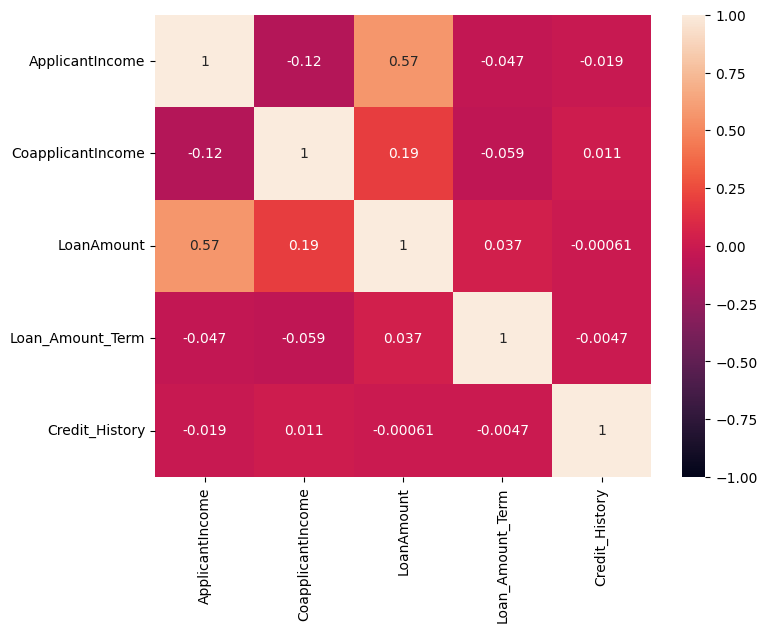

In [15]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),  annot=True, vmin=-1, vmax=1)
plt.show()

In [16]:
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [17]:
df. columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [18]:
df.dropna(axis=0)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [19]:
df.shape

(614, 12)

In [20]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [21]:
#percentage of properties area using  map function
df['Property_Area'].value_counts().map(lambda x:
                                       round((x/df['Property_Area'].value_counts().sum())*100,2))

Property_Area
Semiurban    37.95
Urban        32.90
Rural        29.15
Name: count, dtype: float64

In [22]:
# finding relation between education, loan amount and loan status
df.pivot_table(values = "LoanAmount",
               index = 'Education',
               columns = 'Loan_Status',
               aggfunc = [np.mean, np.median, np.max, np.min])

C:\Users\SUSHANKI\AppData\Local\Temp\ipykernel_3780\1868236427.py:2: FutureWarning: The provided callable <function mean at 0x0000022F22735D20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(values = "LoanAmount",
C:\Users\SUSHANKI\AppData\Local\Temp\ipykernel_3780\1868236427.py:2: FutureWarning: The provided callable <function median at 0x0000022F228609E0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.pivot_table(values = "LoanAmount",
C:\Users\SUSHANKI\AppData\Local\Temp\ipykernel_3780\1868236427.py:2: FutureWarning: The provided callable <function max at 0x0000022F22735220> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current 

mean             median           max          min      
Loan_Status            N           Y      N      Y      N      Y     N     Y
Education                                                                   
Graduate      159.957143  150.482353  132.5  130.0  570.0  700.0   9.0  17.0
Not Graduate  122.788462  116.451220  125.5  114.0  218.0  279.0  35.0  25.0

In [23]:
# analyzing mean income  of applications and co-applicants
df.groupby(['Gender', 'Married'])[['ApplicantIncome','CoapplicantIncome']].mean()

ApplicantIncome  CoapplicantIncome
Gender Married                                    
Female No           4503.787500        1020.012500
       Yes          4992.687500        1328.000000
Male   No           5251.045113        1494.932331
       Yes          5689.067751        1822.552629

In [24]:
# convert categorical columns to numerical using map function
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

**1.** **Loan Approvl Status with Countplot:**

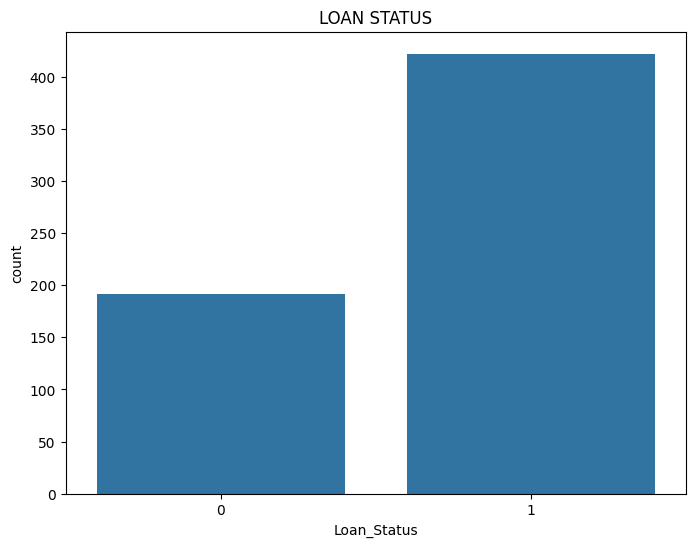

In [25]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['Loan_Status'], data=df)
plt.title('LOAN STATUS')
plt.show()

**Observation** - We can see that the number of loan applications approved id double that of those rejected.

**2. Distribution of Loan Amount :**

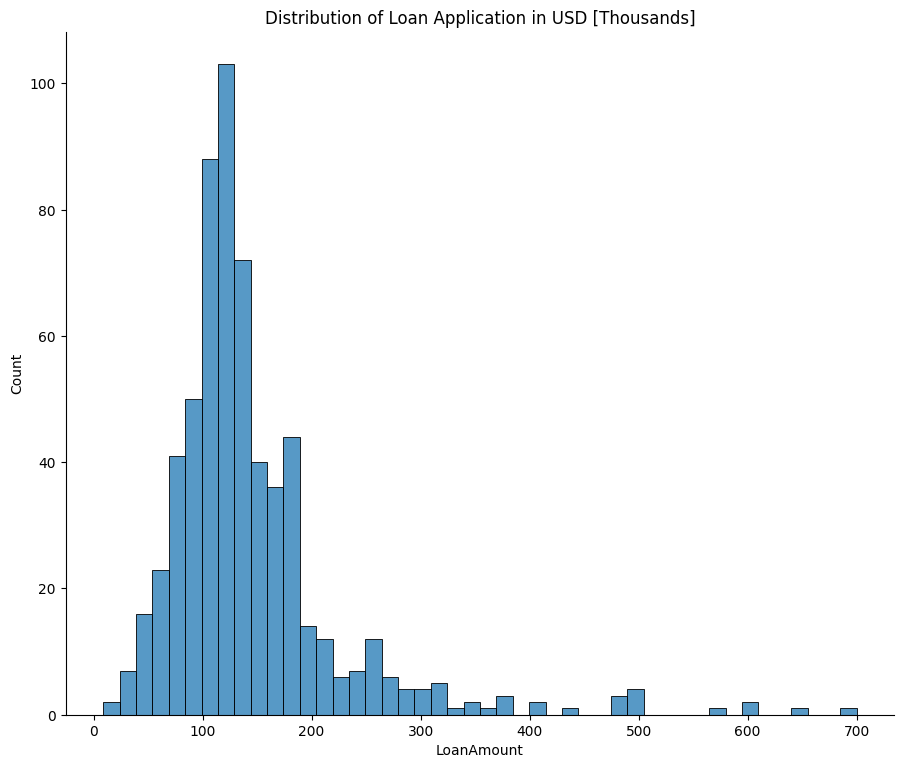

In [26]:
loan_amount = sns.displot(data=df, x ='LoanAmount', legend=True)
plt.title('Distribution of Loan Application in USD [Thousands]')
loan_amount.fig.set_figwidth(10)
loan_amount.fig.set_figheight(8)

***3. Distribution of Loan Amount's Term :***

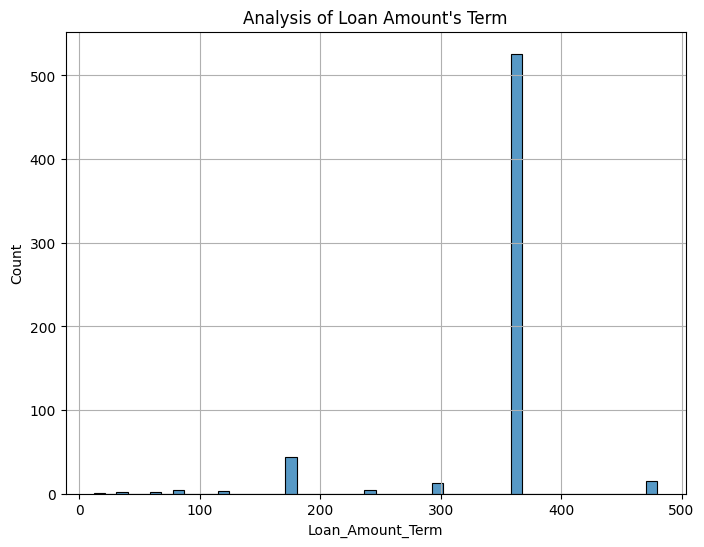

In [27]:
plt.figure(figsize=(8,6))
sns.histplot(x='Loan_Amount_Term', data=df)
plt.title("Analysis of Loan Amount's Term")
plt.grid()
plt.show()

***4. Relationship between Loan Amount and Approval Status with Stripplot :***

Text(0.5, 1.0, 'Salary By Company Size')

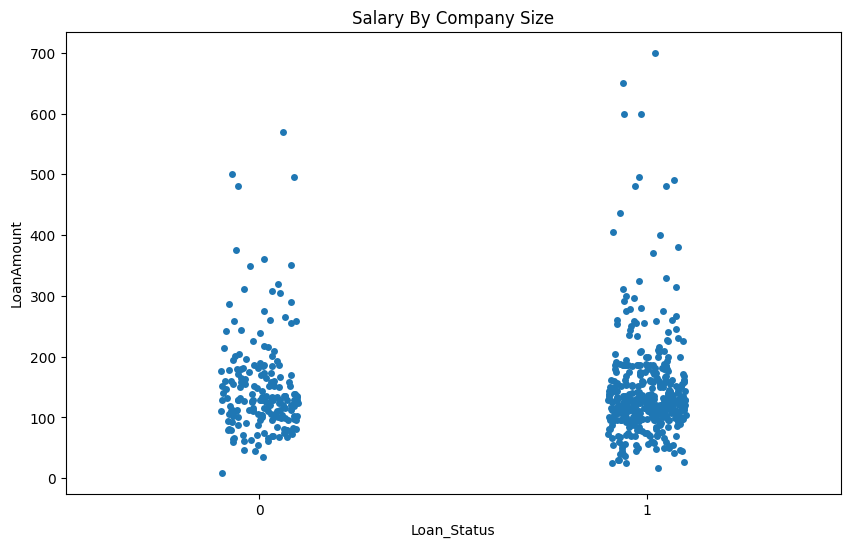

In [28]:
plt.figure(figsize=(10,6))
sns.stripplot(x=df['Loan_Status'],
              y=df['LoanAmount'], data=df).set_title('Salary By Company Size')  

We can see that Loan Approval Status is not directly dependent on Loan Amoount.

**5. Distribution of Gender with Piechart :**

In [29]:
df['Gender'].value_counts()

Gender
Male      502
Female    112
Name: count, dtype: int64

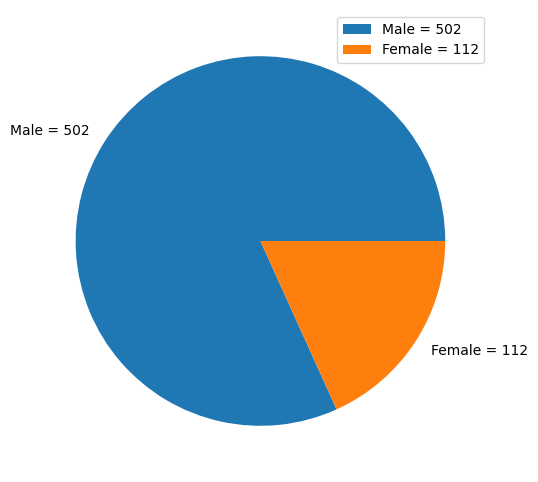

In [31]:
gender = np.array(df['Gender'].value_counts(sort=True))

labels = ['Male = 502', 'Female = 112']

plt.figure(figsize=(8,6))
plt.pie(gender, labels=labels,shadow=False)
plt.legend(labels=labels,
           bbox_to_anchor=(1,1))
plt.show()

We Notice that there were 4.5 times as many male applicants for loans as there were female applications.

**6. Relationship between Applicant Income & LoanAmount :**

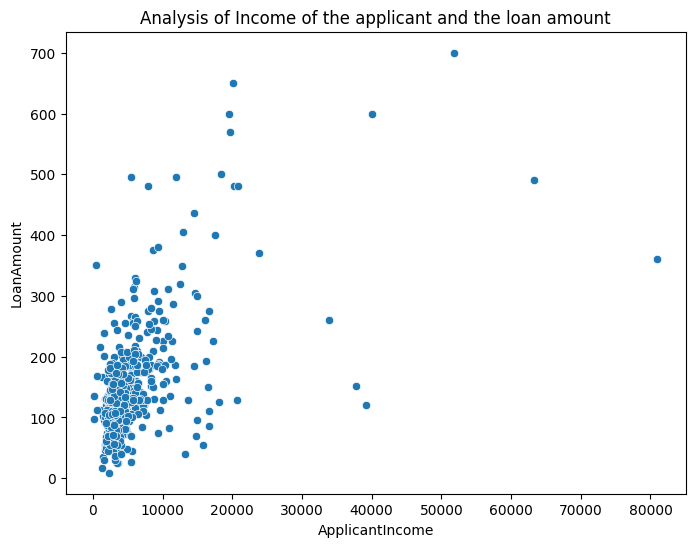

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='ApplicantIncome',
                y='LoanAmount', data=df)
plt.title('Analysis of Income of the applicant and the loan amount')
plt.show()

Most of the applicants have income within and around 10k USD but they have applied loan upto 500k USD

**7. Distribution of Co-applicant's Income :**

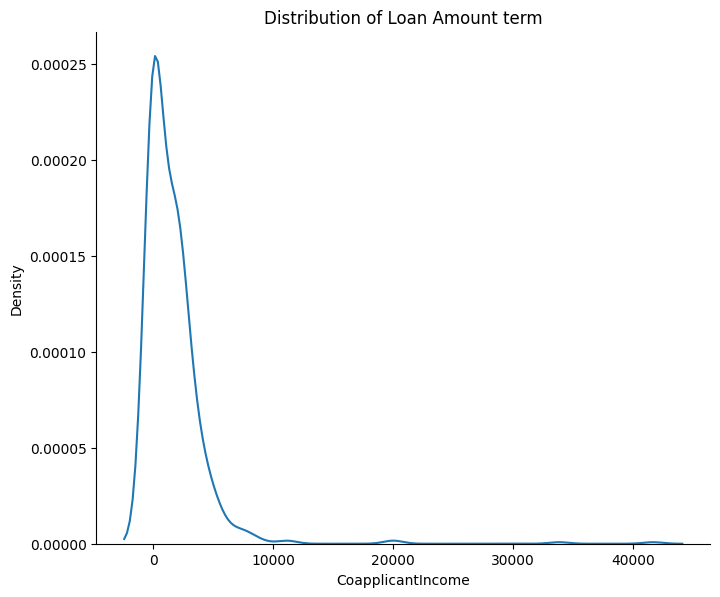

In [35]:
Loan_Amount_Term = sns.displot(data=df, x='CoapplicantIncome', kind='kde')
plt.title('Distribution of Loan Amount term')
Loan_Amount_Term.fig.set_figwidth(8)
Loan_Amount_Term.fig.set_figheight(6)

**8. Analysis the Dataset with pairplot :**

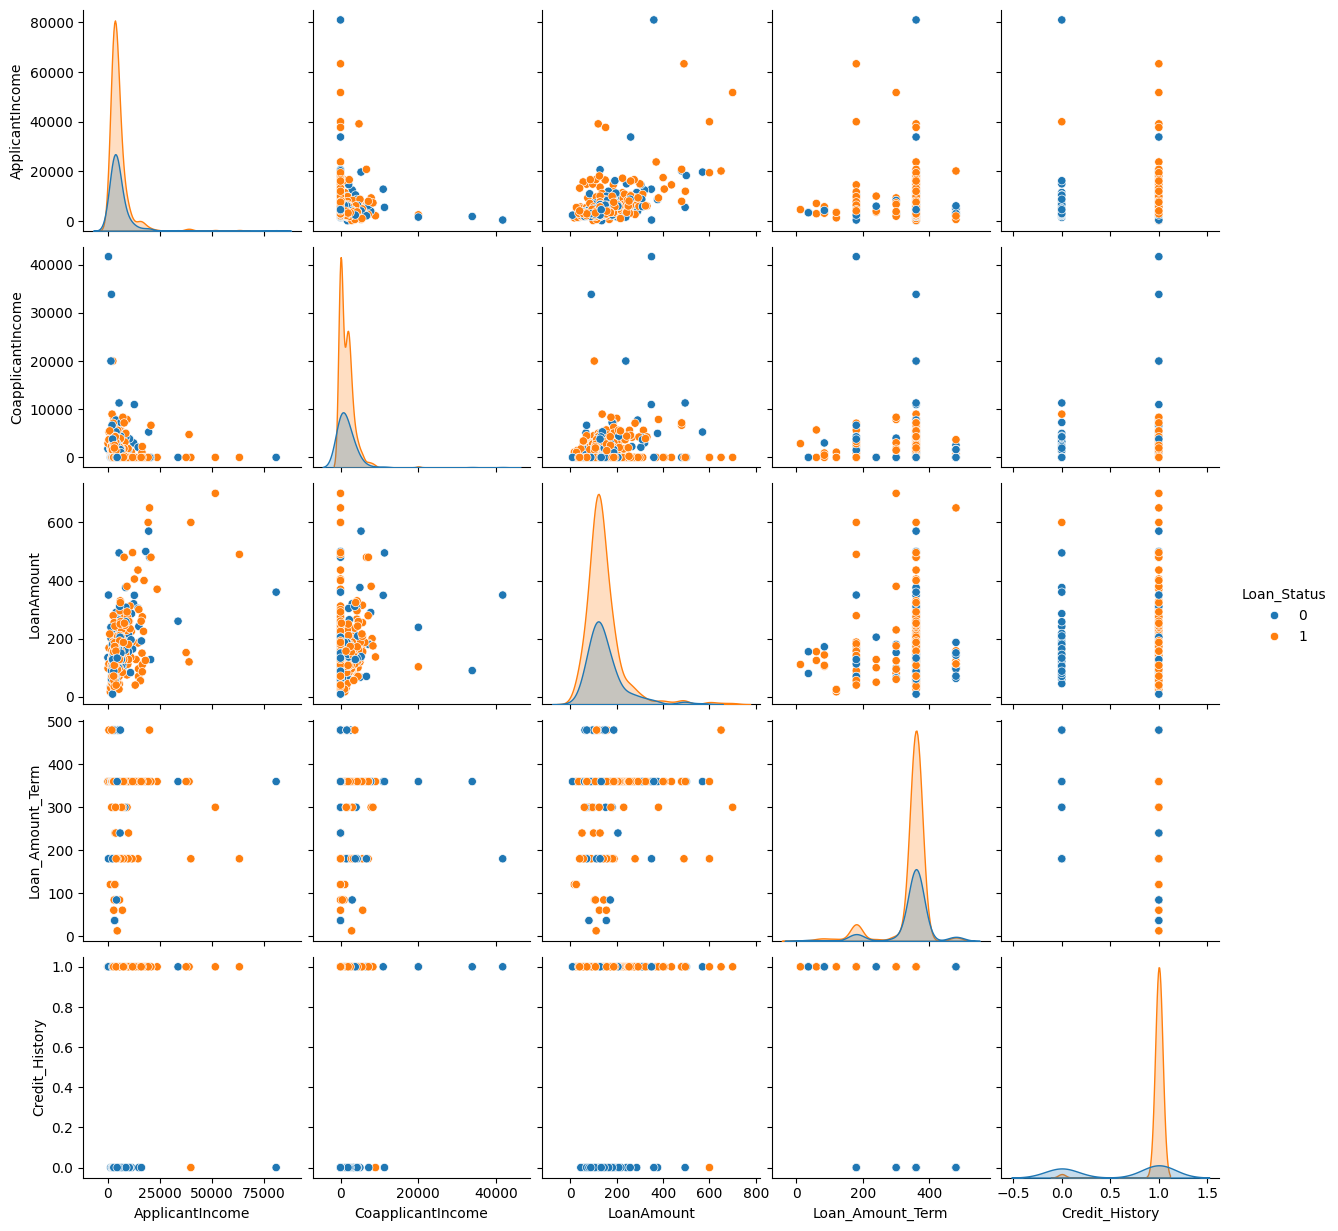

In [37]:
sns.pairplot(df,hue = 'Loan_Status')
plt.show()

**9. Distribution of Loan Amount**

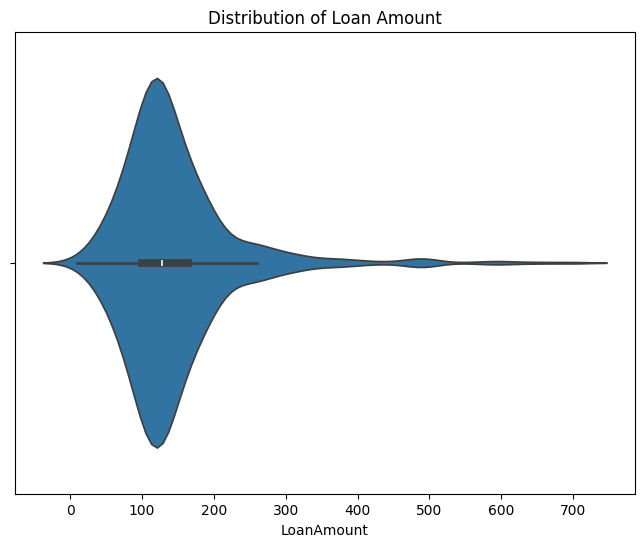

In [38]:
plt.figure(figsize=(8,6))
sns.violinplot(x=df['LoanAmount'])
plt.title('Distribution of Loan Amount')
plt.show()

**10. Analysis of target column with Categorical Column**

In [41]:
# converting Loan_Status datatype from category to integer
df['Loan_Status'] = df['Loan_Status'].astype('int')

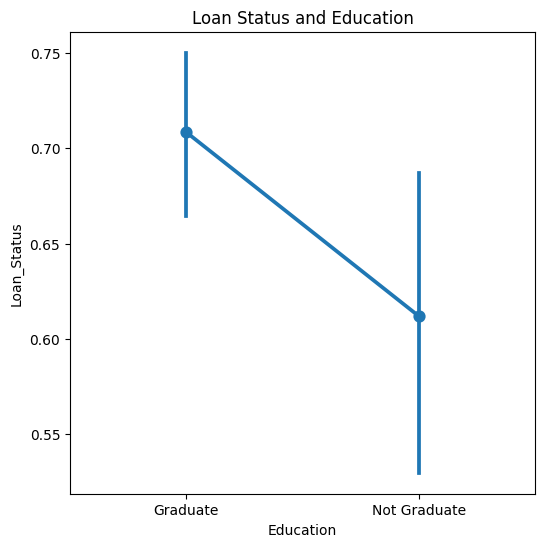

In [42]:
# Point Plot
plt.figure(figsize=(6,6))
sns.pointplot(x='Education',
              y='Loan_Status', data = df)
plt.title("Loan Status and Education")
plt.show()

In [43]:
cat_col =['Gender', 'Married', 'Self_Employed', 'Property_Area']

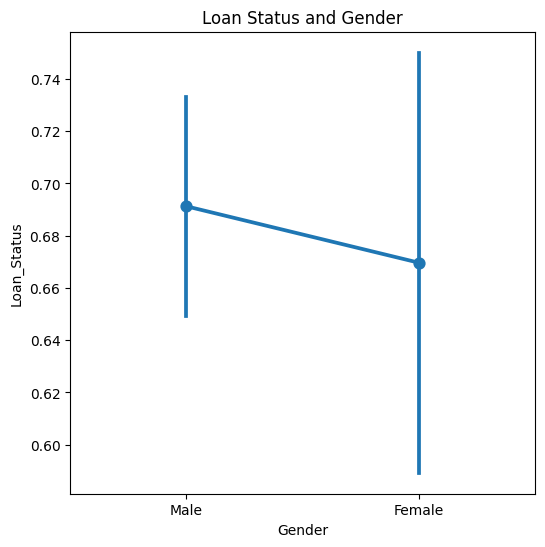

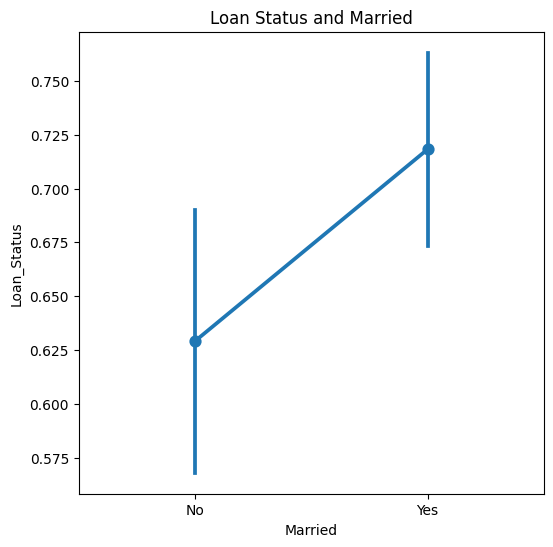

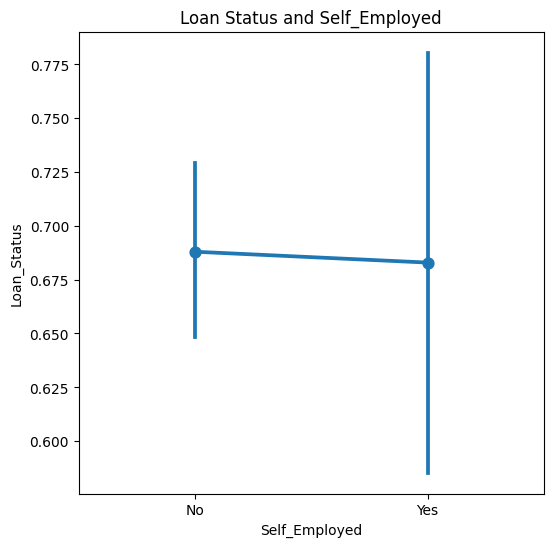

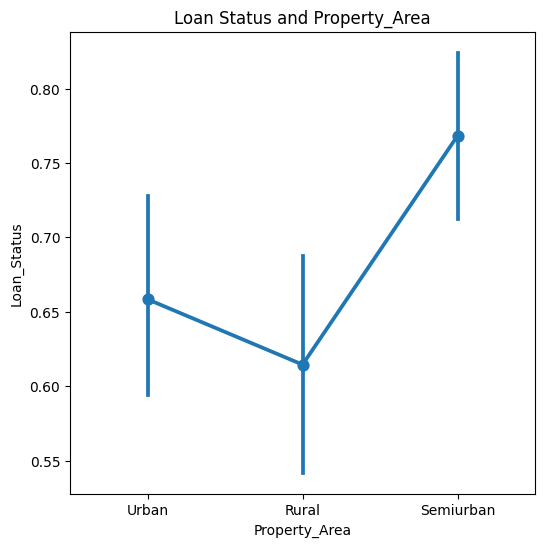

In [44]:
# plot  target vs Categorical columns:
for i, col in enumerate(cat_col):
    plt.figure(i,figsize=(6,6))
    sns.pointplot(x=col,
                  y='Loan_Status', data=df)
    plt.title("Loan Status and {}".format(col))
    plt.show()

**11. Numerical Columns vs Loan_Status**

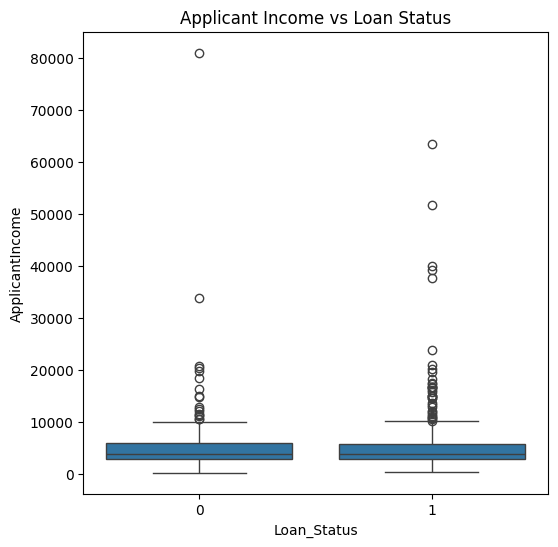

In [72]:
#Income vs Loan Status
plt.figure(figsize=(6,6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Status")
plt.show()

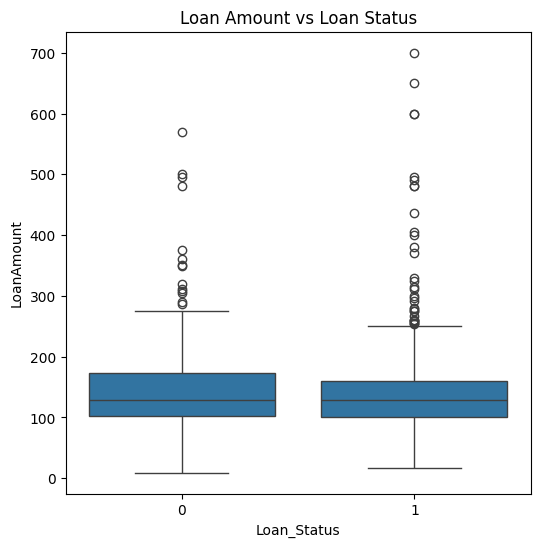

In [73]:
# Loan Amount vs Loan Status
plt.figure(figsize=(6,6))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

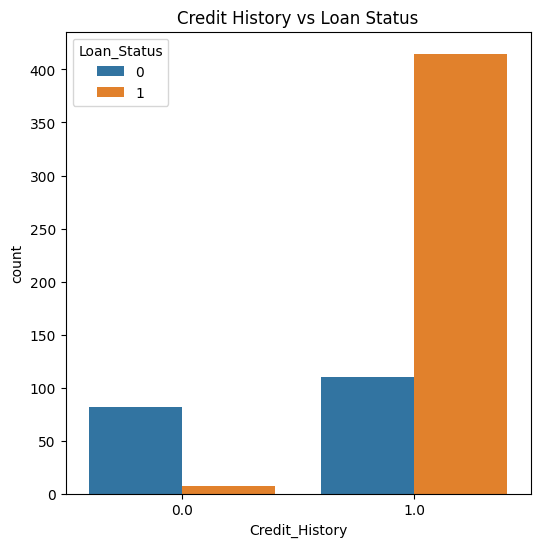

In [74]:
plt.figure(figsize=(6,6))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

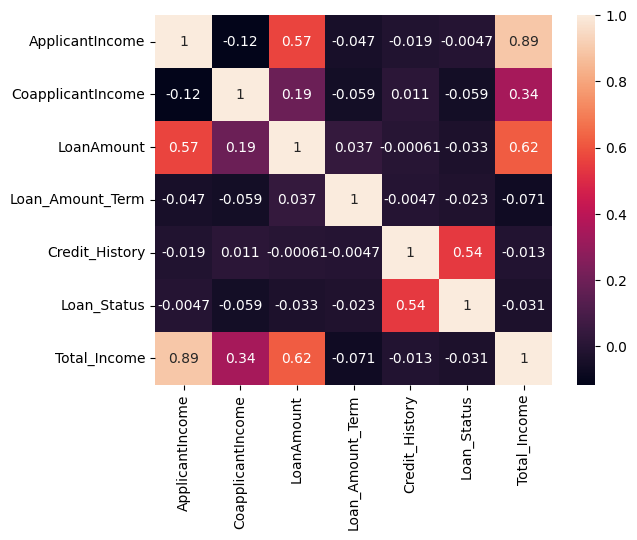

In [75]:
#Correlation check
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

**ML Model**

In [76]:
# Features & target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [78]:
# Encoding
X = pd.get_dummies(X, drop_first=True)

In [80]:
# Train -Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [82]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [83]:
# check Accuracy
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.7398373983739838


In [92]:
df.to_csv("loan_cleaned.csv", index=False)

In [93]:
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']